# Particle Stability and Numerical Behaviour

This notebook summarizes ESS, likelihood-tempering, runtime, and quote-workload diagnostics for the four q160-update / q300-evaluation windows.

The comparison uses five paired seeds for each model.

In [29]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

In [30]:
def find_project_root(start=None):
    here = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing src/ and notebooks/.")


def project_relative(path):
    path = Path(path)
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path


PROJECT_ROOT = find_project_root()
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
COMMON_EVAL_ROOT = OUTPUT_ROOT / "common_eval_q160_eval300"
NONOVERLAP_ROOT = OUTPUT_ROOT / "nonoverlap_q160_eval300"

COMPARISON_ROOT = OUTPUT_ROOT / "comparisons" / "particle_stability_numerical_behaviour"
TABLE_DIR = COMPARISON_ROOT / "tables"
FIGURE_DIR = COMPARISON_ROOT / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = [123, 456, 789, 101112, 131415]
N_PARTICLES = 300
MODEL_ORDER = ["Markovian SABR", "Rough-SABR"]
MODEL_COLORS = {"Markovian SABR": "#4c78a8", "Rough-SABR": "#d65225"}

WINDOWS = [
    {
        "key": "w0_400",
        "label": "0-399",
        "start": 0,
        "base": COMMON_EVAL_ROOT,
        "normal_pattern": "normal_400ts_q160_eval300_seed{seed}",
        "rough_pattern": "rough_400ts_q160_eval300_seed{seed}",
    },
    {
        "key": "w401_800",
        "label": "400-799",
        "start": 400,
        "base": NONOVERLAP_ROOT / "w401_800",
        "normal_pattern": "normal_sabr_no_A_RW_seed{seed}",
        "rough_pattern": "rough_sabr_logU0_seed{seed}",
    },
    {
        "key": "w801_1200",
        "label": "800-1199",
        "start": 800,
        "base": NONOVERLAP_ROOT / "w801_1200",
        "normal_pattern": "normal_sabr_no_A_RW_seed{seed}",
        "rough_pattern": "rough_sabr_logU0_seed{seed}",
    },
    {
        "key": "w1201_1600",
        "label": "1200-1599",
        "start": 1200,
        "base": NONOVERLAP_ROOT / "w1201_1600",
        "normal_pattern": "normal_sabr_no_A_RW_seed{seed}",
        "rough_pattern": "rough_sabr_logU0_seed{seed}",
    },
]
WINDOW_ORDER = [w["key"] for w in WINDOWS]
WINDOW_LABELS = {w["key"]: w["label"] for w in WINDOWS}
WINDOW_STARTS = {w["key"]: w["start"] for w in WINDOWS}

RUN_SPECS = []
for window in WINDOWS:
    for seed in SEEDS:
        RUN_SPECS.extend(
            [
                {
                    "window_key": window["key"],
                    "window": window["label"],
                    "window_start": window["start"],
                    "model": "Markovian SABR",
                    "seed": seed,
                    "run_dir": window["base"] / window["normal_pattern"].format(seed=seed),
                },
                {
                    "window_key": window["key"],
                    "window": window["label"],
                    "window_start": window["start"],
                    "model": "Rough-SABR",
                    "seed": seed,
                    "run_dir": window["base"] / window["rough_pattern"].format(seed=seed),
                },
            ]
        )

## Run Inventory

This checks that each paired run has the ESS and runtime diagnostics needed below.

In [31]:
inventory = pd.DataFrame(
    [
        {
            "window_key": spec["window_key"],
            "window": spec["window"],
            "model": spec["model"],
            "seed": spec["seed"],
            "run_dir": str(project_relative(spec["run_dir"])),
            "has_run_dir": spec["run_dir"].exists(),
            "has_ess": (spec["run_dir"] / "ess.csv").exists(),
            "has_runtime": (spec["run_dir"] / "runtime_by_timestamp.csv").exists(),
            "has_summary_eval": (spec["run_dir"] / "model_comparison_summary_eval.csv").exists(),
        }
        for spec in RUN_SPECS
    ]
)
inventory["window_key"] = pd.Categorical(inventory["window_key"], categories=WINDOW_ORDER, ordered=True)
inventory["model"] = pd.Categorical(inventory["model"], categories=MODEL_ORDER, ordered=True)
inventory = inventory.sort_values(["window_key", "model", "seed"]).reset_index(drop=True)

inventory_summary = (
    inventory.groupby(["window_key", "window", "model"], observed=True)
    .agg(
        n_seeds=("seed", "nunique"),
        seeds=("seed", lambda s: ", ".join(str(int(x)) for x in sorted(s.unique()))),
        run_dirs=("has_run_dir", "sum"),
        ess_files=("has_ess", "sum"),
        runtime_files=("has_runtime", "sum"),
    )
    .reset_index()
    .drop(columns="window_key")
)
inventory.to_csv(TABLE_DIR / "particle_stability_run_inventory.csv", index=False)
inventory_summary.to_csv(TABLE_DIR / "particle_stability_run_inventory_summary.csv", index=False)
display(inventory_summary)

missing = inventory.loc[~(inventory["has_run_dir"] & inventory["has_ess"] & inventory["has_runtime"])]
if len(missing):
    display(missing[["window", "model", "seed", "run_dir", "has_run_dir", "has_ess", "has_runtime"]])
    raise FileNotFoundError("Some required particle-stability diagnostics are missing; see the table above.")

,window,model,n_seeds,seeds,run_dirs,ess_files,runtime_files
0,0-399,Markovian SABR,5,"123, 456, 789, 101112, 131415",5,5,5
1,0-399,Rough-SABR,5,"123, 456, 789, 101112, 131415",5,5,5
2,400-799,Markovian SABR,5,"123, 456, 789, 101112, 131415",5,5,5
3,400-799,Rough-SABR,5,"123, 456, 789, 101112, 131415",5,5,5
4,800-1199,Markovian SABR,5,"123, 456, 789, 101112, 131415",5,5,5
5,800-1199,Rough-SABR,5,"123, 456, 789, 101112, 131415",5,5,5
6,1200-1599,Markovian SABR,5,"123, 456, 789, 101112, 131415",5,5,5
7,1200-1599,Rough-SABR,5,"123, 456, 789, 101112, 131415",5,5,5


## Load Diagnostics

The notebook reads `ess.csv` and `runtime_by_timestamp.csv` from each run.

In [32]:
ESS_COLUMNS = [
    "capture_time_utc",
    "t_index",
    "ess",
    "pre_update_ess",
    "min_tempered_ess",
    "n_tempering_steps",
    "n_tempering_resamples",
]
RUNTIME_COLUMNS = [
    "capture_time_utc",
    "t_index",
    "n_quotes",
    "predict_seconds",
    "likelihood_seconds",
    "predictive_eval_seconds",
    "update_seconds",
    "evaluation_seconds",
    "timestamp_seconds",
]


def load_run_file(spec, file_name, required_columns):
    path = spec["run_dir"] / file_name
    df = pd.read_csv(path)
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns in {project_relative(path)}: {missing_columns}")

    out = df[required_columns].copy()
    out.insert(0, "window_key", spec["window_key"])
    out.insert(1, "window", spec["window"])
    out.insert(2, "window_start", spec["window_start"])
    out.insert(3, "model", spec["model"])
    out.insert(4, "seed", spec["seed"])
    out.insert(5, "run_dir", str(project_relative(spec["run_dir"])))
    return out


ess_all = pd.concat(
    [load_run_file(spec, "ess.csv", ESS_COLUMNS) for spec in RUN_SPECS],
    ignore_index=True,
)
runtime_all = pd.concat(
    [load_run_file(spec, "runtime_by_timestamp.csv", RUNTIME_COLUMNS) for spec in RUN_SPECS],
    ignore_index=True,
)

for frame in (ess_all, runtime_all):
    frame["capture_time_utc"] = pd.to_datetime(frame["capture_time_utc"], utc=True)
    frame["window_key"] = pd.Categorical(frame["window_key"], categories=WINDOW_ORDER, ordered=True)
    frame["model"] = pd.Categorical(frame["model"], categories=MODEL_ORDER, ordered=True)
    frame["relative_t_index"] = frame["t_index"] - frame["window_start"]
    frame.sort_values(["window_key", "model", "seed", "t_index"], inplace=True)

for column in ["ess", "pre_update_ess", "min_tempered_ess", "n_tempering_steps", "n_tempering_resamples"]:
    ess_all[column] = pd.to_numeric(ess_all[column], errors="coerce")

for column in ["n_quotes", "predict_seconds", "likelihood_seconds", "predictive_eval_seconds", "update_seconds", "evaluation_seconds", "timestamp_seconds"]:
    runtime_all[column] = pd.to_numeric(runtime_all[column], errors="coerce")

ess_all["ess_frac"] = ess_all["ess"] / N_PARTICLES
ess_all["pre_update_ess_frac"] = ess_all["pre_update_ess"] / N_PARTICLES
ess_all["min_tempered_ess_frac"] = ess_all["min_tempered_ess"] / N_PARTICLES
ess_all["tempering_active"] = ess_all["n_tempering_steps"] > 0
ess_all["tempering_resampled"] = ess_all["n_tempering_resamples"] > 0

sample_check = (
    ess_all.groupby(["window_key", "window", "model", "seed"], observed=True)
    .agg(
        n_ess_timestamps=("t_index", "nunique"),
        first_t_index=("t_index", "min"),
        last_t_index=("t_index", "max"),
    )
    .reset_index()
    .merge(
        runtime_all.groupby(["window_key", "window", "model", "seed"], observed=True)
        .agg(
            n_runtime_timestamps=("t_index", "nunique"),
            mean_quotes=("n_quotes", "mean"),
        )
        .reset_index(),
        on=["window_key", "window", "model", "seed"],
        how="left",
    )
    .sort_values(["window_key", "model", "seed"])
)
sample_check.to_csv(TABLE_DIR / "particle_stability_sample_check.csv", index=False)
display(sample_check.drop(columns="window_key").head(12))

,window,model,seed,n_ess_timestamps,first_t_index,last_t_index,n_runtime_timestamps,mean_quotes
0,0-399,Markovian SABR,123,400,0,399,400,154.485
1,0-399,Markovian SABR,456,400,0,399,400,154.485
2,0-399,Markovian SABR,789,400,0,399,400,154.485
3,0-399,Markovian SABR,101112,400,0,399,400,154.485
4,0-399,Markovian SABR,131415,400,0,399,400,154.485
5,0-399,Rough-SABR,123,400,0,399,400,154.485
6,0-399,Rough-SABR,456,400,0,399,400,154.485
7,0-399,Rough-SABR,789,400,0,399,400,154.485
8,0-399,Rough-SABR,101112,400,0,399,400,154.485
9,0-399,Rough-SABR,131415,400,0,399,400,154.485


## Main Numerical Summary

This table summarizes particle stability, tempering effort, runtime, and quote workload across all four windows.

In [33]:
ess_summary = (
    ess_all.groupby("model", observed=True)
    .agg(
        number_of_windows=("window", "nunique"),
        number_of_seeds=("seed", "nunique"),
        timestamp_seed_observations=("t_index", "size"),
        mean_pre_update_ess=("pre_update_ess", "mean"),
        mean_post_update_ess=("ess", "mean"),
        p05_post_update_ess=("ess", lambda x: x.quantile(0.05)),
        min_post_update_ess=("ess", "min"),
        mean_min_tempered_ess=("min_tempered_ess", "mean"),
        p05_min_tempered_ess=("min_tempered_ess", lambda x: x.quantile(0.05)),
        mean_tempering_steps=("n_tempering_steps", "mean"),
        mean_tempering_resamples=("n_tempering_resamples", "mean"),
        tempering_active_rate=("tempering_active", "mean"),
        tempering_resample_rate=("tempering_resampled", "mean"),
    )
    .reset_index()
)

runtime_summary = (
    runtime_all.groupby("model", observed=True)
    .agg(
        mean_timestamp_seconds=("timestamp_seconds", "mean"),
        median_timestamp_seconds=("timestamp_seconds", "median"),
        p95_timestamp_seconds=("timestamp_seconds", lambda x: x.quantile(0.95)),
        total_runtime_hours=("timestamp_seconds", lambda x: x.sum() / 3600.0),
        mean_predict_seconds=("predict_seconds", "mean"),
        mean_likelihood_seconds=("likelihood_seconds", "mean"),
        mean_predictive_eval_seconds=("predictive_eval_seconds", "mean"),
        mean_update_seconds=("update_seconds", "mean"),
        mean_evaluation_seconds=("evaluation_seconds", "mean"),
        mean_n_quotes=("n_quotes", "mean"),
    )
    .reset_index()
)

model_summary = ess_summary.merge(runtime_summary, on="model", how="left")
normal_runtime = float(model_summary.loc[model_summary["model"] == "Markovian SABR", "mean_timestamp_seconds"].iloc[0])
model_summary["runtime_multiple_vs_normal"] = model_summary["mean_timestamp_seconds"] / normal_runtime
model_summary["model"] = pd.Categorical(model_summary["model"], categories=MODEL_ORDER, ordered=True)
model_summary = model_summary.sort_values("model").reset_index(drop=True)

model_summary.to_csv(TABLE_DIR / "particle_stability_model_summary_full.csv", index=False)

main_summary = model_summary[
    [
        "model",
        "number_of_windows",
        "number_of_seeds",
        "mean_post_update_ess",
        "p05_post_update_ess",
        "min_post_update_ess",
        "mean_min_tempered_ess",
        "mean_tempering_steps",
        "mean_tempering_resamples",
        "tempering_resample_rate",
        "mean_timestamp_seconds",
        "runtime_multiple_vs_normal",
        "mean_n_quotes",
    ]
].copy()
main_summary.to_csv(TABLE_DIR / "particle_stability_model_summary_display.csv", index=False)
display(main_summary.round(3))

,model,number_of_windows,number_of_seeds,mean_post_update_ess,p05_post_update_ess,min_post_update_ess,mean_min_tempered_ess,mean_tempering_steps,mean_tempering_resamples,tempering_resample_rate,mean_timestamp_seconds,runtime_multiple_vs_normal,mean_n_quotes
0,Markovian SABR,4,5,263.739,216.198,210.001,210.0,6.606,5.606,1.0,5.722,1.000,156.793
1,Rough-SABR,4,5,263.320,215.781,210.000,210.0,6.603,5.603,1.0,18.793,3.284,156.793


## Window Summary

This is the same diagnostic split by non-overlapping window.

In [34]:
ess_window_summary = (
    ess_all.groupby(["window_key", "window", "model"], observed=True)
    .agg(
        number_of_seeds=("seed", "nunique"),
        timestamp_seed_observations=("t_index", "size"),
        mean_post_update_ess=("ess", "mean"),
        p05_post_update_ess=("ess", lambda x: x.quantile(0.05)),
        min_post_update_ess=("ess", "min"),
        mean_min_tempered_ess=("min_tempered_ess", "mean"),
        mean_tempering_steps=("n_tempering_steps", "mean"),
        mean_tempering_resamples=("n_tempering_resamples", "mean"),
        tempering_resample_rate=("tempering_resampled", "mean"),
    )
    .reset_index()
)
runtime_window_summary = (
    runtime_all.groupby(["window_key", "window", "model"], observed=True)
    .agg(
        mean_timestamp_seconds=("timestamp_seconds", "mean"),
        median_timestamp_seconds=("timestamp_seconds", "median"),
        p95_timestamp_seconds=("timestamp_seconds", lambda x: x.quantile(0.95)),
        total_runtime_hours=("timestamp_seconds", lambda x: x.sum() / 3600.0),
        mean_n_quotes=("n_quotes", "mean"),
    )
    .reset_index()
)
window_summary = ess_window_summary.merge(
    runtime_window_summary,
    on=["window_key", "window", "model"],
    how="left",
)
normal_by_window = (
    window_summary[window_summary["model"] == "Markovian SABR"]
    .set_index("window_key")["mean_timestamp_seconds"]
)
window_summary["runtime_multiple_vs_window_normal"] = window_summary.apply(
    lambda row: row["mean_timestamp_seconds"] / normal_by_window.loc[row["window_key"]],
    axis=1,
)
window_summary = window_summary.sort_values(["window_key", "model"]).reset_index(drop=True)
window_summary.to_csv(TABLE_DIR / "particle_stability_window_summary.csv", index=False)

window_view = window_summary[
    [
        "window",
        "model",
        "number_of_seeds",
        "mean_post_update_ess",
        "min_post_update_ess",
        "mean_min_tempered_ess",
        "mean_tempering_steps",
        "mean_tempering_resamples",
        "mean_timestamp_seconds",
        "runtime_multiple_vs_window_normal",
        "mean_n_quotes",
    ]
].copy()
display(window_view.round(3))

,window,model,number_of_seeds,mean_post_update_ess,min_post_update_ess,mean_min_tempered_ess,mean_tempering_steps,mean_tempering_resamples,mean_timestamp_seconds,runtime_multiple_vs_window_normal,mean_n_quotes
0,0-399,Markovian SABR,5,264.678,210.005,210.0,6.068,5.068,2.516,1.000,154.485
1,0-399,Rough-SABR,5,263.738,210.068,210.0,5.972,4.972,12.237,4.864,154.485
2,400-799,Markovian SABR,5,263.632,210.057,210.0,6.701,5.701,6.414,1.000,156.625
3,400-799,Rough-SABR,5,262.820,210.014,210.0,6.730,5.730,21.539,3.358,156.625
4,800-1199,Markovian SABR,5,261.946,210.001,210.0,6.973,5.973,6.866,1.000,158.302
5,800-1199,Rough-SABR,5,262.499,210.000,210.0,6.954,5.954,23.387,3.406,158.302
6,1200-1599,Markovian SABR,5,264.698,210.089,210.0,6.682,5.682,7.093,1.000,157.760
7,1200-1599,Rough-SABR,5,264.222,210.007,210.0,6.758,5.758,18.010,2.539,157.760


## Paired Seed Check

This checks whether the model-level numerical differences are stable across seeds and windows.

In [35]:
seed_window_ess = (
    ess_all.groupby(["window_key", "window", "model", "seed"], observed=True)
    .agg(
        mean_post_update_ess=("ess", "mean"),
        min_post_update_ess=("ess", "min"),
        mean_min_tempered_ess=("min_tempered_ess", "mean"),
        mean_tempering_steps=("n_tempering_steps", "mean"),
        total_tempering_resamples=("n_tempering_resamples", "sum"),
    )
    .reset_index()
)
seed_window_runtime = (
    runtime_all.groupby(["window_key", "window", "model", "seed"], observed=True)
    .agg(
        mean_timestamp_seconds=("timestamp_seconds", "mean"),
        total_runtime_minutes=("timestamp_seconds", lambda x: x.sum() / 60.0),
        mean_n_quotes=("n_quotes", "mean"),
    )
    .reset_index()
)
seed_window_summary = seed_window_ess.merge(
    seed_window_runtime,
    on=["window_key", "window", "model", "seed"],
    how="left",
)

wide = seed_window_summary.pivot(index=["window_key", "window", "seed"], columns="model")
paired_seed_window = pd.DataFrame(
    {
        "window_key": wide.index.get_level_values("window_key"),
        "window": wide.index.get_level_values("window"),
        "seed": wide.index.get_level_values("seed"),
        "rough_minus_normal_mean_ess": wide[("mean_post_update_ess", "Rough-SABR")].to_numpy()
        - wide[("mean_post_update_ess", "Markovian SABR")].to_numpy(),
        "rough_minus_normal_min_ess": wide[("min_post_update_ess", "Rough-SABR")].to_numpy()
        - wide[("min_post_update_ess", "Markovian SABR")].to_numpy(),
        "rough_minus_normal_tempering_steps": wide[("mean_tempering_steps", "Rough-SABR")].to_numpy()
        - wide[("mean_tempering_steps", "Markovian SABR")].to_numpy(),
        "rough_minus_normal_tempering_resamples": wide[("total_tempering_resamples", "Rough-SABR")].to_numpy()
        - wide[("total_tempering_resamples", "Markovian SABR")].to_numpy(),
        "rough_runtime_multiple_vs_normal": wide[("mean_timestamp_seconds", "Rough-SABR")].to_numpy()
        / wide[("mean_timestamp_seconds", "Markovian SABR")].to_numpy(),
        "rough_minus_normal_mean_quotes": wide[("mean_n_quotes", "Rough-SABR")].to_numpy()
        - wide[("mean_n_quotes", "Markovian SABR")].to_numpy(),
    }
)
paired_seed_window["window_key"] = pd.Categorical(paired_seed_window["window_key"], categories=WINDOW_ORDER, ordered=True)
paired_seed_window = paired_seed_window.sort_values(["window_key", "seed"]).reset_index(drop=True)
paired_seed_window.to_csv(TABLE_DIR / "particle_stability_paired_seed_window_differences.csv", index=False)

paired_window_summary = (
    paired_seed_window.groupby(["window_key", "window"], observed=True)
    .agg(
        mean_rough_minus_normal_ess=("rough_minus_normal_mean_ess", "mean"),
        min_rough_minus_normal_ess=("rough_minus_normal_min_ess", "min"),
        mean_rough_minus_normal_tempering_steps=("rough_minus_normal_tempering_steps", "mean"),
        mean_rough_minus_normal_tempering_resamples=("rough_minus_normal_tempering_resamples", "mean"),
        mean_rough_runtime_multiple_vs_normal=("rough_runtime_multiple_vs_normal", "mean"),
        max_abs_mean_quote_difference=("rough_minus_normal_mean_quotes", lambda x: np.abs(x).max()),
    )
    .reset_index()
    .drop(columns="window_key")
)
paired_window_summary.to_csv(TABLE_DIR / "particle_stability_paired_window_summary.csv", index=False)
display(paired_window_summary.round(3))
display(paired_seed_window.drop(columns="window_key").round(3))

,window,mean_rough_minus_normal_ess,min_rough_minus_normal_ess,mean_rough_minus_normal_tempering_steps,mean_rough_minus_normal_tempering_resamples,mean_rough_runtime_multiple_vs_normal,max_abs_mean_quote_difference
0,0-399,-0.939,-0.469,-0.096,-38.6,5.086,0.0
1,400-799,-0.812,-0.680,0.029,11.6,3.403,0.0
2,800-1199,0.553,-0.028,-0.019,-7.6,3.418,0.0
3,1200-1599,-0.476,-1.001,0.075,30.0,2.581,0.0


,window,seed,rough_minus_normal_mean_ess,rough_minus_normal_min_ess,rough_minus_normal_tempering_steps,rough_minus_normal_tempering_resamples,rough_runtime_multiple_vs_normal,rough_minus_normal_mean_quotes
0,0-399,123,-0.798,-0.122,-0.067,-27,3.061,0.0
1,0-399,456,-0.143,0.012,-0.043,-17,2.803,0.0
2,0-399,789,-0.513,-0.469,-0.265,-106,1.636,0.0
3,0-399,101112,-1.419,-0.431,-0.088,-35,2.112,0.0
4,0-399,131415,-1.825,1.061,-0.020,-8,15.816,0.0
5,400-799,123,-1.589,-0.261,-0.015,-6,3.076,0.0
6,400-799,456,2.255,-0.680,0.035,14,3.481,0.0
7,400-799,789,-2.463,-0.039,0.112,45,2.808,0.0
8,400-799,101112,-0.565,0.135,0.005,2,3.788,0.0
9,400-799,131415,-1.695,-0.428,0.008,3,3.864,0.0


## ESS and Tempering Paths

The figure shows raw seed-averaged paths inside each window. It keeps the two diagnostics that are easiest to interpret directly: post-update ESS and the number of likelihood-tempering steps.

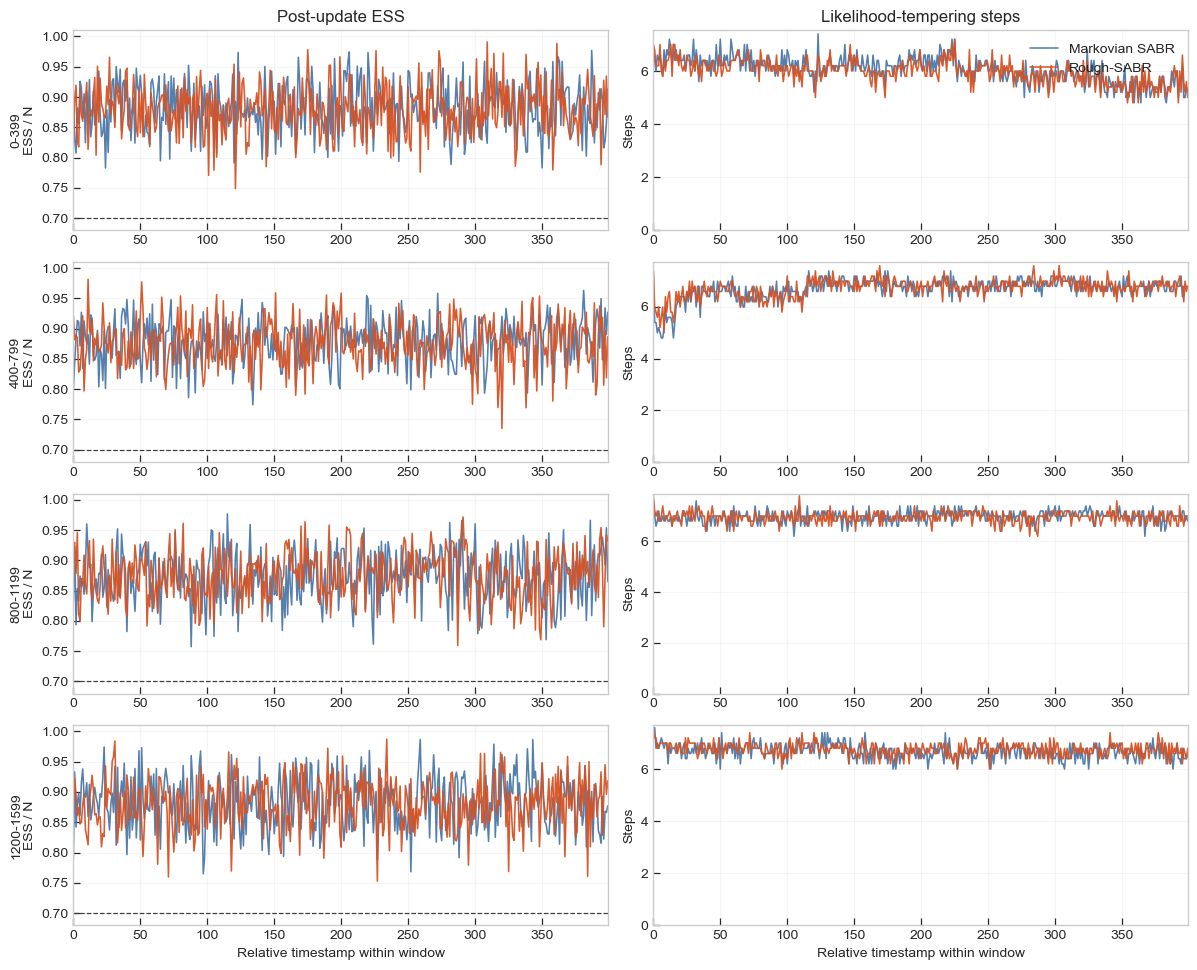

Saved: outputs\comparisons\particle_stability_numerical_behaviour\figures\particle_stability_ess_tempering_by_window.png


In [36]:
timestamp_diag = (
    ess_all.groupby(["window_key", "window", "model", "relative_t_index"], observed=True)
    .agg(
        mean_ess_frac=("ess_frac", "mean"),
        q05_ess_frac=("ess_frac", lambda x: x.quantile(0.05)),
        q95_ess_frac=("ess_frac", lambda x: x.quantile(0.95)),
        mean_tempering_resamples=("n_tempering_resamples", "mean"),
        q05_tempering_resamples=("n_tempering_resamples", lambda x: x.quantile(0.05)),
        q95_tempering_resamples=("n_tempering_resamples", lambda x: x.quantile(0.95)),
        mean_tempering_steps=("n_tempering_steps", "mean"),
        q05_tempering_steps=("n_tempering_steps", lambda x: x.quantile(0.05)),
        q95_tempering_steps=("n_tempering_steps", lambda x: x.quantile(0.95)),
    )
    .reset_index()
    .sort_values(["window_key", "model", "relative_t_index"])
)
timestamp_diag.to_csv(TABLE_DIR / "particle_stability_timestamp_ess_tempering_summary.csv", index=False)

fig, axes = plt.subplots(len(WINDOW_ORDER), 2, figsize=(12, 2.45 * len(WINDOW_ORDER)), sharex="row")

plot_columns = [
    ("mean_ess_frac", "Post-update ESS", "ESS / N"),
    ("mean_tempering_steps", "Likelihood-tempering steps", "Steps"),
]

for row, window_key in enumerate(WINDOW_ORDER):
    for model in MODEL_ORDER:
        h = timestamp_diag[(timestamp_diag["window_key"] == window_key) & (timestamp_diag["model"] == model)]
        if h.empty:
            continue
        x = h["relative_t_index"].to_numpy(dtype=float)
        color = MODEL_COLORS[model]

        for col, (metric, _, _) in enumerate(plot_columns):
            axes[row, col].plot(
                x,
                h[metric],
                color=color,
                linewidth=1.15,
                alpha=0.95,
                label=model,
            )

    axes[row, 0].axhline(0.70, color="0.25", linestyle="--", linewidth=0.9)
    axes[row, 0].set_ylim(0.68, 1.01)
    axes[row, 1].set_ylim(bottom=0)
    axes[row, 0].set_ylabel(f"{WINDOW_LABELS[window_key]}\nESS / N")
    axes[row, 1].set_ylabel("Steps")

    for col in range(2):
        axes[row, col].grid(alpha=0.18)
        axes[row, col].tick_params(axis="both", which="major", direction="in", labelsize=10, length=5, width=0.9)
        axes[row, col].set_xlim(0, 399)

for col, (_, title, _) in enumerate(plot_columns):
    axes[0, col].set_title(title)
axes[0, 1].legend(loc="upper right", frameon=False)

for col in range(2):
    axes[-1, col].set_xlabel("Relative timestamp within window")

fig.tight_layout()
path = FIGURE_DIR / "particle_stability_ess_tempering_by_window.png"
fig.savefig(path, bbox_inches="tight", dpi=220)
plt.show()
print("Saved:", project_relative(path))

## Runtime Diagnostics

The runtime figure reports the dominant components. The full component table is displayed underneath.

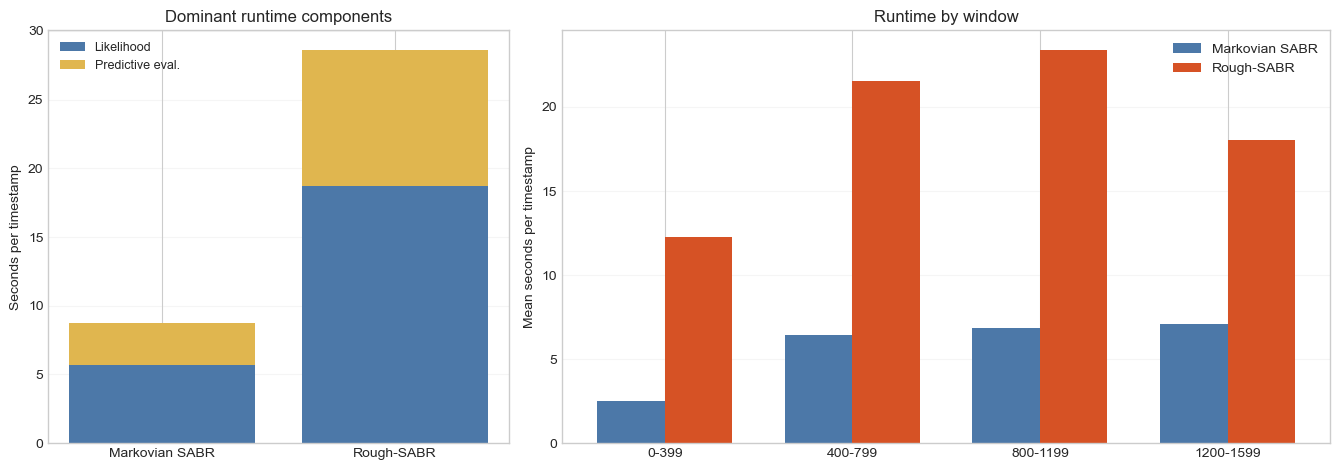

Saved: outputs\comparisons\particle_stability_numerical_behaviour\figures\particle_stability_runtime_diagnostics.png


,Prediction,Likelihood,Predictive eval.,Update,Other eval.
model,,,,,
Markovian SABR,0.000,5.672,3.075,0.011,0.037
Rough-SABR,0.001,18.693,9.918,0.011,0.086


,window,model,mean_timestamp_seconds
0,0-399,Markovian SABR,2.516
1,0-399,Rough-SABR,12.237
2,400-799,Markovian SABR,6.414
3,400-799,Rough-SABR,21.539
4,800-1199,Markovian SABR,6.866
5,800-1199,Rough-SABR,23.387
6,1200-1599,Markovian SABR,7.093
7,1200-1599,Rough-SABR,18.010


In [37]:
runtime_components = [
    "predict_seconds",
    "likelihood_seconds",
    "predictive_eval_seconds",
    "update_seconds",
    "evaluation_seconds",
]
component_labels = {
    "predict_seconds": "Prediction",
    "likelihood_seconds": "Likelihood",
    "predictive_eval_seconds": "Predictive eval.",
    "update_seconds": "Update",
    "evaluation_seconds": "Other eval.",
}

component_summary = (
    runtime_all.groupby("model", observed=True)[runtime_components]
    .mean()
    .reindex(MODEL_ORDER)
)
component_summary.reset_index().to_csv(TABLE_DIR / "particle_stability_runtime_component_summary.csv", index=False)

runtime_by_window = (
    runtime_all.groupby(["window_key", "window", "model"], observed=True)
    .agg(mean_timestamp_seconds=("timestamp_seconds", "mean"))
    .reset_index()
    .sort_values(["window_key", "model"])
)
runtime_by_window.to_csv(TABLE_DIR / "particle_stability_runtime_by_window.csv", index=False)

runtime_stack = pd.DataFrame(
    {
        "Likelihood": component_summary["likelihood_seconds"],
        "Predictive eval.": component_summary["predictive_eval_seconds"],
    }
)
runtime_colors = ["#4c78a8", "#e0b64f"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), gridspec_kw={"width_ratios": [0.9, 1.5]})

xpos = np.arange(len(runtime_stack))
bottom = np.zeros(len(runtime_stack))
for component, color in zip(runtime_stack.columns, runtime_colors):
    values = runtime_stack[component].to_numpy(dtype=float)
    axes[0].bar(xpos, values, bottom=bottom, color=color, label=component)
    bottom += values

axes[0].set_xticks(xpos)
axes[0].set_xticklabels(component_summary.index)
axes[0].set_ylabel("Seconds per timestamp")
axes[0].set_title("Dominant runtime components")
axes[0].legend(loc="upper left", frameon=False, fontsize=9)
axes[0].grid(axis="y", alpha=0.18)

bar_width = 0.36
window_positions = np.arange(len(WINDOW_ORDER))
for offset, model in zip([-bar_width / 2, bar_width / 2], MODEL_ORDER):
    values = (
        runtime_by_window[runtime_by_window["model"] == model]
        .set_index("window_key")
        .reindex(WINDOW_ORDER)["mean_timestamp_seconds"]
        .to_numpy(dtype=float)
    )
    axes[1].bar(window_positions + offset, values, width=bar_width, color=MODEL_COLORS[model], label=model)

axes[1].set_xticks(window_positions)
axes[1].set_xticklabels([WINDOW_LABELS[w] for w in WINDOW_ORDER])
axes[1].set_ylabel("Mean seconds per timestamp")
axes[1].set_title("Runtime by window")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.18)

fig.tight_layout()
path = FIGURE_DIR / "particle_stability_runtime_diagnostics.png"
fig.savefig(path, bbox_inches="tight", dpi=220)
plt.show()
print("Saved:", project_relative(path))

component_display = component_summary.rename(columns=component_labels)
display(component_display.round(3))
display(runtime_by_window.drop(columns="window_key").round(3))

## Quote Workload

This checks whether the two filters processed the same number of quotes.

In [38]:
quote_workload = (
    runtime_all.groupby(["window_key", "window", "model", "seed"], observed=True)
    .agg(
        total_quotes=("n_quotes", "sum"),
        mean_quotes_per_timestamp=("n_quotes", "mean"),
        min_quotes_per_timestamp=("n_quotes", "min"),
        max_quotes_per_timestamp=("n_quotes", "max"),
    )
    .reset_index()
    .sort_values(["window_key", "seed", "model"])
)
quote_workload.to_csv(TABLE_DIR / "particle_stability_quote_workload_by_seed.csv", index=False)

quote_wide = quote_workload.pivot(index=["window_key", "window", "seed"], columns="model", values="total_quotes")
paired_quote_check = pd.DataFrame(
    {
        "window_key": quote_wide.index.get_level_values("window_key"),
        "window": quote_wide.index.get_level_values("window"),
        "seed": quote_wide.index.get_level_values("seed"),
        "normal_total_quotes": quote_wide["Markovian SABR"].to_numpy(),
        "rough_total_quotes": quote_wide["Rough-SABR"].to_numpy(),
    }
)
paired_quote_check["rough_minus_normal_total_quotes"] = (
    paired_quote_check["rough_total_quotes"] - paired_quote_check["normal_total_quotes"]
)
paired_quote_check["window_key"] = pd.Categorical(paired_quote_check["window_key"], categories=WINDOW_ORDER, ordered=True)
paired_quote_check = paired_quote_check.sort_values(["window_key", "seed"]).reset_index(drop=True)
paired_quote_check.to_csv(TABLE_DIR / "particle_stability_paired_quote_workload_check.csv", index=False)

quote_window_check = (
    paired_quote_check.groupby(["window_key", "window"], observed=True)
    .agg(
        seeds=("seed", "nunique"),
        normal_total_quotes=("normal_total_quotes", "sum"),
        rough_total_quotes=("rough_total_quotes", "sum"),
        max_abs_seed_quote_difference=("rough_minus_normal_total_quotes", lambda x: np.abs(x).max()),
    )
    .reset_index()
    .drop(columns="window_key")
)
quote_window_check.to_csv(TABLE_DIR / "particle_stability_quote_workload_by_window.csv", index=False)
display(quote_window_check)

,window,seeds,normal_total_quotes,rough_total_quotes,max_abs_seed_quote_difference
0,0-399,5,308970,308970,0
1,400-799,5,313250,313250,0
2,800-1199,5,316605,316605,0
3,1200-1599,5,315520,315520,0
